# Tech Challenge Fase 4 - LSTM Stock Price Prediction

Este notebook implementa um modelo LSTM completo para previsão de preços de ações, incluindo:
1. Coleta de dados com yfinance
2. Pré-processamento e normalização
3. Construção e treinamento do modelo LSTM
4. Avaliação e métricas de performance
5. Salvamento do modelo para deploy em API

**Empresa escolhida:** Apple (AAPL)  
**Período de dados:** Últimos 5 anos  
**Métricas de avaliação:** MAE, RMSE, MAPE

## 1. Instalçao e importação das bibliotecas.

In [2]:
pip install -r ../requirements.txt

Note: you may need to restart the kernel to use updated packages.


In [3]:
import sys
sys.path.append('/home/raulg/dev/laughing-couscous')

# Dados e finanças
import yfinance as yf
import pandas as pd
import numpy as np

# Métricas
from sklearn.preprocessing import MinMaxScaler
from sklearn.metrics import mean_absolute_error, mean_squared_error, mean_absolute_percentage_error

# Deep Learning
import tensorflow as tf
from tensorflow import keras
from tensorflow.keras import layers, models
from tensorflow.keras.callbacks import EarlyStopping, ReduceLROnPlateau

# Gráficos
import matplotlib.pyplot as plt
import seaborn as sns
from datetime import datetime, timedelta
import warnings

# Outras coisas que a IA me disse para importar
from src.data.data_collector import StockDataCollector, DataPreprocessor
from src.models.lstm_model import LSTMModel

warnings.filterwarnings('ignore')
plt.style.use('seaborn-v0_8-darkgrid')
sns.set_palette("husl")

print("✓ Parece que funciona!")
print(f"TensorFlow : {tf.__version__}")
print(f"Pandas : {pd.__version__}")
print(f"NumPy : {np.__version__}")

I0000 00:00:1779229047.687514   20926 cudart_stub.cc:31] Could not find cuda drivers on your machine, GPU will not be used.
I0000 00:00:1779229048.261113   20926 cpu_feature_guard.cc:227] This TensorFlow binary is optimized to use available CPU instructions in performance-critical operations.
To enable the following instructions: AVX2 FMA, in other operations, rebuild TensorFlow with the appropriate compiler flags.
I0000 00:00:1779229049.879416   20926 cudart_stub.cc:31] Could not find cuda drivers on your machine, GPU will not be used.


✓ Parece que funciona!
TensorFlow : 2.21.0
Pandas : 3.0.3
NumPy : 2.4.5


## 2. Coleta de dados

Coletaremos dados históricos de preços de ações da Apple (AAPL) dos últimos 5 anos.

In [4]:
# Configuração
STOCK_SYMBOL = 'AAPL'  # Apple Inc.
START_DATE = '2019-01-01'
END_DATE = datetime.now().strftime('%Y-%m-%d')

print(f"Obtendo dados da {STOCK_SYMBOL} de {START_DATE} até {END_DATE}...")

# Classe de coleta de dados
collector = StockDataCollector(STOCK_SYMBOL, START_DATE, END_DATE)

# Download
df = collector.download()

# Exibir informações básicas
print(f"\n📊 Resumo dos Dados:")
print(f"Papel: {STOCK_SYMBOL}")
print(f"Total de registros: {len(df)}")
print(f"Data: {df.index.min().date()} a {df.index.max().date()}")
print(f"\nPrimeiras linhas:")
print(df.head())
print(f"\nEstatísticas:")
print(df.describe())

# Verificar valores ausentes
missing = df.isnull().sum()
if missing.any():
    print(f"\n⚠️ Valores ausentes:\n{missing[missing > 0]}")
else:
    print("\n✓ Nenhum valor ausente encontrado!")
    
# Obter informações da empresa
info = collector.get_info()
print(f"\nDados da Empresa:")
for key, value in info.items():
    print(f"  {key}: {value}")

INFO:src.data.data_collector:StockDataCollector inicializado para AAPL de 2019-01-01 a 2026-05-19
INFO:src.data.data_collector:Baixando dados para AAPL...


Obtendo dados da AAPL de 2019-01-01 até 2026-05-19...


INFO:src.data.data_collector:Baixados 1854 registros



📊 Resumo dos Dados:
Papel: AAPL
Total de registros: 1854
Data: 2019-01-02 a 2026-05-18

Primeiras linhas:
Price           Close       High        Low       Open     Volume
Ticker           AAPL       AAPL       AAPL       AAPL       AAPL
Date                                                             
2019-01-02  37.469204  37.689864  36.593688  36.750285  148158800
2019-01-03  33.737000  34.574552  33.691918  34.161706  365248800
2019-01-04  35.177212  35.246021  34.119003  34.292207  234428400
2019-01-07  35.098907  35.312450  34.617256  35.281604  219111200
2019-01-08  35.768002  36.021879  35.238897  35.485653  164101200

Estatísticas:
Price         Close         High          Low         Open        Volume
Ticker         AAPL         AAPL         AAPL         AAPL          AAPL
count   1854.000000  1854.000000  1854.000000  1854.000000  1.854000e+03
mean     154.117073   155.674992   152.403265   153.966331  8.639227e+07
std       64.897901    65.455149    64.293332    64.852743

## 3. Pré Processamento

Vamos explorar o comportamento do preço de fechamento da ação ao longo do tempo.

In [5]:
# Estatísticas adicionais
print("\n📈 Estatísticas do Preço de Fechamento:")
print(f"Mean: ${np.mean(df['Close'].values):.2f}")
print(f"Median: ${np.median(df['Close'].values):.2f}")
print(f"Min: ${np.min(df['Close'].values):.2f}")
print(f"Max: ${np.max(df['Close'].values):.2f}")
print(f"Std Dev: ${np.std(df['Close'].values):.2f}")


📈 Estatísticas do Preço de Fechamento:
Mean: $154.12
Median: $154.34
Min: $33.74
Max: $300.23
Std Dev: $64.88


👆 Eu faço esse tipo de coisa, mas não que eu entenda alguma coisa de mercado financeiro.
Fica a dica para no próximo curso utilizar dados de Pokemons.

## 4. Normalização e sequencia de dados

Normalizaremos os dados e criaremos sequências para treinar o modelo LSTM.

INFO:src.data.data_collector:Iniciando processamento de dados...
INFO:src.data.data_collector:Amostras de treinamento: 1239
INFO:src.data.data_collector:Amostras de validação: 125
INFO:src.data.data_collector:Amostras de teste: 310


Configuração de pré-processamento:
  Período de retrospectiva: 60 dias
  Tamanho do conjunto de teste: 20.0%
  Tamanho do conjunto de validação: 10.0%

✓ Dados preparados com sucesso!
Forma de X_train: (1239, 60)
Forma de y_train: (1239,)
Forma de X_val: (125, 60)
Forma de y_val: (125,)
Forma de X_test: (310, 60)
Forma de y_test: (310,)


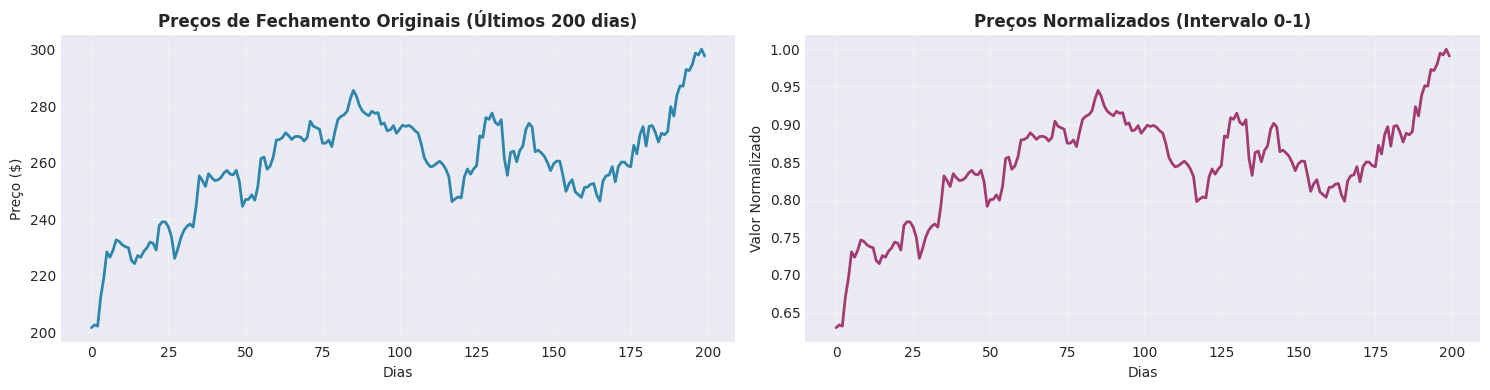

✓ Visualização de normalização salva!


In [6]:
# Configuração para pré-processamento
LOOKBACK_PERIOD = 60  # Número de dias a olhar para trás
TEST_SIZE = 0.2
VAL_SIZE = 0.1

print(f"Configuração de pré-processamento:")
print(f"  Período de retrospectiva: {LOOKBACK_PERIOD} dias")
print(f"  Tamanho do conjunto de teste: {TEST_SIZE * 100}%")
print(f"  Tamanho do conjunto de validação: {VAL_SIZE * 100}%")

# Criar pré-processador
preprocessor = DataPreprocessor(df, lookback=LOOKBACK_PERIOD)

# Preparar dados
data_dict, info_dict = preprocessor.prepare_data(test_size=TEST_SIZE, val_size=VAL_SIZE)

# Extrair dados de treinamento
X_train = data_dict['X_train']
y_train = data_dict['y_train']
X_val = data_dict['X_val']
y_val = data_dict['y_val']
X_test = data_dict['X_test']
y_test = data_dict['y_test']

scaler = info_dict['scaler']

print(f"\n✓ Dados preparados com sucesso!")
print(f"Forma de X_train: {X_train.shape}")
print(f"Forma de y_train: {y_train.shape}")
print(f"Forma de X_val: {X_val.shape}")
print(f"Forma de y_val: {y_val.shape}")
print(f"Forma de X_test: {X_test.shape}")
print(f"Forma de y_test: {y_test.shape}")

# Visualizar dados normalizados
fig, axes = plt.subplots(1, 2, figsize=(15, 4))

# Original vs Normalizado
original_prices = df['Close'].values[-200:]
axes[0].plot(original_prices, linewidth=2, color='#2E86AB')
axes[0].set_title('Preços de Fechamento Originais (Últimos 200 dias)', fontsize=12, fontweight='bold')
axes[0].set_xlabel('Dias')
axes[0].set_ylabel('Preço ($)')
axes[0].grid(True, alpha=0.3)

normalized_prices = scaler.transform(df[['Close']].values)[-200:]
axes[1].plot(normalized_prices, linewidth=2, color='#A23B72')
axes[1].set_title('Preços Normalizados (Intervalo 0-1)', fontsize=12, fontweight='bold')
axes[1].set_xlabel('Dias')
axes[1].set_ylabel('Valor Normalizado')
axes[1].grid(True, alpha=0.3)

plt.tight_layout()
plt.savefig('/home/raulg/dev/laughing-couscous/models/02_normalization.png', dpi=150, bbox_inches='tight')
plt.show()

print("✓ Visualização de normalização salva!")

## 5. Contruindo o modelo.

Construiremos um modelo LSTM com múltiplas camadas para capturar padrões temporais.

In [7]:
# Configuração do modelo
LSTM_UNITS = 50
DROPOUT_RATE = 0.2

print(f"Construindo modelo LSTM com:")
print(f"  Período de retrospectiva de entrada: {LOOKBACK_PERIOD} passos")
print(f"  Unidades LSTM: {LSTM_UNITS}")
print(f"  Taxa de dropout: {DROPOUT_RATE}")

# Criar e construir modelo
lstm_model = LSTMModel(lookback=LOOKBACK_PERIOD, units=LSTM_UNITS, dropout=DROPOUT_RATE)
model = lstm_model.build()

print("\n✓ Arquitetura do modelo criada!")
print("\nResumo do Modelo:")
print(model.summary())

INFO:src.models.lstm_model:Modelo LSTM inicializado com lookback=60, units=50, dropout=0.2
E0000 00:00:1779229052.767881   20926 cuda_platform.cc:52] failed call to cuInit: INTERNAL: CUDA error: Failed call to cuInit: UNKNOWN ERROR (303)
INFO:src.models.lstm_model:Modelo LSTM construído com sucesso


Construindo modelo LSTM com:
  Período de retrospectiva de entrada: 60 passos
  Unidades LSTM: 50
  Taxa de dropout: 0.2


Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ lstm (LSTM)                     │ (None, 60, 50)         │        10,400 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 60, 50)         │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ lstm_1 (LSTM)                   │ (None, 60, 50)         │        20,200 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ (None, 60, 50)         │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ lstm_2 (LSTM)                   │ (None, 50)             │        20,200 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_2 (Dropout)             │ (None, 50)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 25)             │         1,275 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 1)              │            26 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 52,101 (203.52 KB)

...

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ lstm (LSTM)                     │ (None, 60, 50)         │        10,400 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 60, 50)         │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ lstm_1 (LSTM)                   │ (None, 60, 50)         │        20,200 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ (None, 60, 50)         │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ lstm_2 (LSTM)                   │ (None, 50)             │        20,200 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_2 (Dropout)             │ (None, 50)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 25)             │         1,275 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 1)              │            26 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 52,101 (203.52 KB)

 Trainable params: 52,101 (203.52 KB)

 Non-trainable params: 0 (0.00 B)

None


## 6. Treinando o modelo LSTM

Treinaremos o modelo com os dados de treinamento e validação.

Configuração de treinamento:
  Épocas: 50
  Tamanho do lote: 32
  Total de amostras de treinamento: 1239
  Total de amostras de validação: 125

📊 Iniciando treinamento do modelo...
Epoch 1/50
39/39 ━━━━━━━━━━━━━━━━━━━━ 5s 53ms/step - loss: 0.0223 - mae: 0.1045 - val_loss: 0.0028 - val_mae: 0.0469 - learning_rate: 0.0010
Epoch 2/50
39/39 ━━━━━━━━━━━━━━━━━━━━ 2s 42ms/step - loss: 0.0023 - mae: 0.0366 - val_loss: 9.8626e-04 - val_mae: 0.0248 - learning_rate: 0.0010
Epoch 3/50
39/39 ━━━━━━━━━━━━━━━━━━━━ 2s 42ms/step - loss: 0.0019 - mae: 0.0329 - val_loss: 0.0025 - val_mae: 0.0433 - learning_rate: 0.0010
Epoch 4/50
39/39 ━━━━━━━━━━━━━━━━━━━━ 4s 716ms/step - loss: 0.0017 - mae: 0.0309 - val_loss: 0.0022 - val_mae: 0.0405 - learning_rate: 0.0010
Epoch 5/50
39/39 ━━━━━━━━━━━━━━━━━━━━ 2s 42ms/step - loss: 0.0016 - mae: 0.0302 - val_loss: 0.0025 - val_mae: 0.0442 - learning_rate: 0.0010
Epoch 6/50
39/39 ━━━━━━━━━━━━━━━━━━━━ 2s 43ms/step - loss: 0.0017 - mae: 0.0305 - val_loss: 0.0030 - val_mae:

INFO:src.models.lstm_model:Treinamento do modelo concluído



✓ Treinamento concluído!


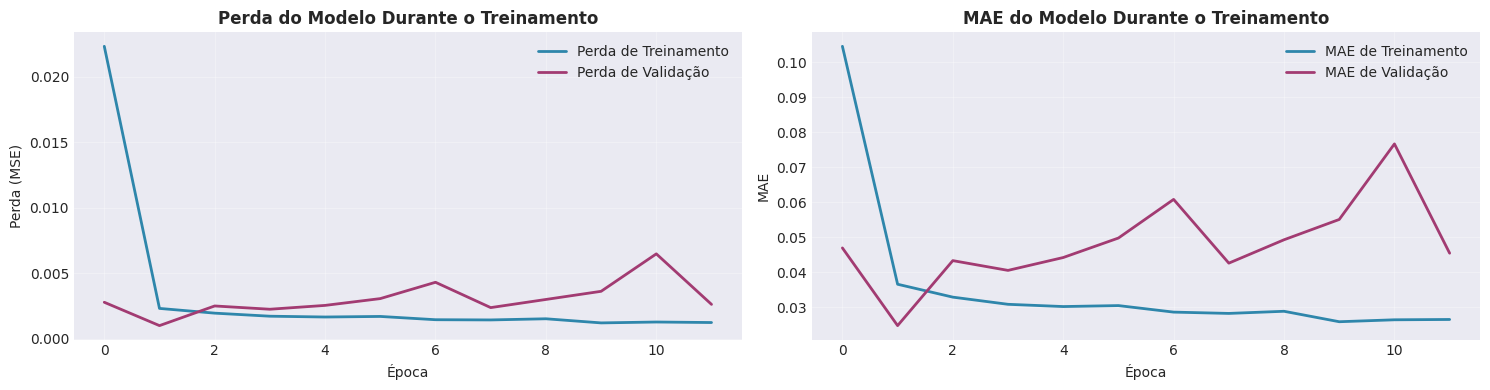

✓ Visualização do histórico de treinamento salva!


In [8]:
# Configuração de treinamento
EPOCHS = 50
BATCH_SIZE = 32

print(f"Configuração de treinamento:")
print(f"  Épocas: {EPOCHS}")
print(f"  Tamanho do lote: {BATCH_SIZE}")
print(f"  Total de amostras de treinamento: {len(X_train)}")
print(f"  Total de amostras de validação: {len(X_val)}")

print("\n📊 Iniciando treinamento do modelo...")
print("=" * 60)

# Treinar o modelo
history = lstm_model.train(
    X_train, y_train,
    X_val, y_val,
    epochs=EPOCHS,
    batch_size=BATCH_SIZE,
    verbose=1
)

print("\n✓ Treinamento concluído!")

# Plotar histórico de treinamento
fig, axes = plt.subplots(1, 2, figsize=(15, 4))

# Perda
axes[0].plot(history['loss'], label='Perda de Treinamento', linewidth=2, color='#2E86AB')
axes[0].plot(history['val_loss'], label='Perda de Validação', linewidth=2, color='#A23B72')
axes[0].set_title('Perda do Modelo Durante o Treinamento', fontsize=12, fontweight='bold')
axes[0].set_xlabel('Época')
axes[0].set_ylabel('Perda (MSE)')
axes[0].legend()
axes[0].grid(True, alpha=0.3)

# MAE
axes[1].plot(history['mae'], label='MAE de Treinamento', linewidth=2, color='#2E86AB')
axes[1].plot(history['val_mae'], label='MAE de Validação', linewidth=2, color='#A23B72')
axes[1].set_title('MAE do Modelo Durante o Treinamento', fontsize=12, fontweight='bold')
axes[1].set_xlabel('Época')
axes[1].set_ylabel('MAE')
axes[1].legend()
axes[1].grid(True, alpha=0.3)

plt.tight_layout()
plt.savefig('/home/raulg/dev/laughing-couscous/models/03_training_history.png', dpi=150, bbox_inches='tight')
plt.show()

print("✓ Visualização do histórico de treinamento salva!")

## 7. Avaliando a performance do modelo.

Avaliaremos o modelo usando as métricas MAE, RMSE e MAPE.

Avaliando modelo em diferentes conjuntos de dados...


INFO:src.models.lstm_model:Métricas de Avaliação - MAE: 5.8647, RMSE: 7.6145, MAPE: 0.0526
INFO:src.models.lstm_model:Métricas de Avaliação - MAE: 6.6003, RMSE: 8.3692, MAPE: 0.0302



📈 Métricas do Conjunto de Treinamento:
  MAE: 5.864699
  RMSE: 7.614460
  MAPE: 0.052630

📈 Métricas do Conjunto de Validação:
  MAE: 6.600288
  RMSE: 8.369155
  MAPE: 0.030170


INFO:src.models.lstm_model:Métricas de Avaliação - MAE: 11.1175, RMSE: 13.9886, MAPE: 0.0455



📈 Métricas do Conjunto de Teste:
  MAE: 11.117527
  RMSE: 13.988560
  MAPE: 0.045499


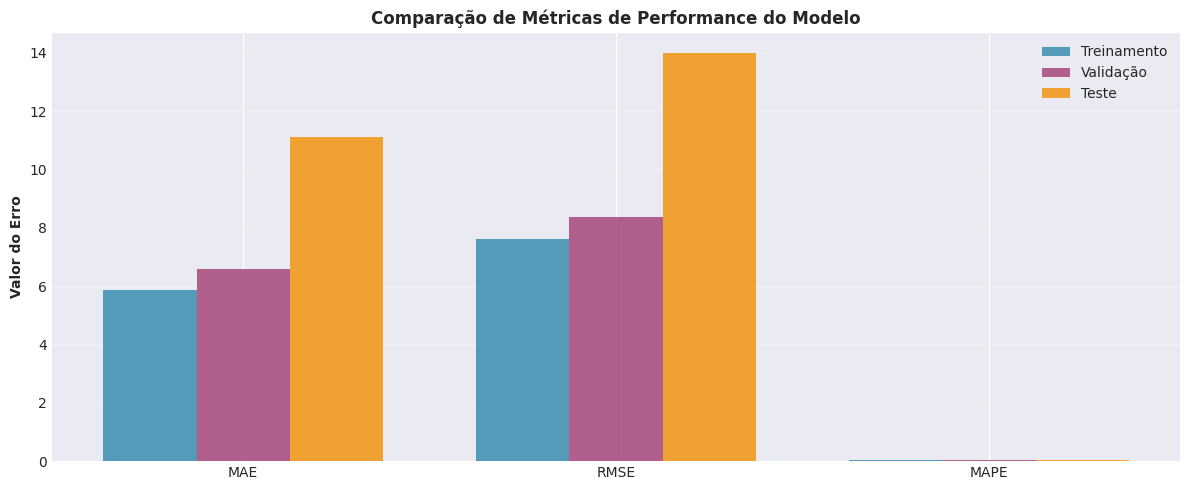


✓ Avaliação do modelo concluída!


In [9]:
print("Avaliando modelo em diferentes conjuntos de dados...")
print("=" * 60)

# Avaliar no conjunto de treinamento
train_metrics = lstm_model.evaluate(X_train, y_train, scaler)
print(f"\n📈 Métricas do Conjunto de Treinamento:")
for metric, value in train_metrics.items():
    print(f"  {metric}: {value:.6f}")

# Avaliar no conjunto de validação
val_metrics = lstm_model.evaluate(X_val, y_val, scaler)
print(f"\n📈 Métricas do Conjunto de Validação:")
for metric, value in val_metrics.items():
    print(f"  {metric}: {value:.6f}")

# Avaliar no conjunto de teste
test_metrics = lstm_model.evaluate(X_test, y_test, scaler)
print(f"\n📈 Métricas do Conjunto de Teste:")
for metric, value in test_metrics.items():
    print(f"  {metric}: {value:.6f}")

# Criar visualização de comparação
fig, ax = plt.subplots(figsize=(12, 5))

metrics_names = list(test_metrics.keys())
train_values = [train_metrics[m] for m in metrics_names]
val_values = [val_metrics[m] for m in metrics_names]
test_values = [test_metrics[m] for m in metrics_names]

x = np.arange(len(metrics_names))
width = 0.25

bars1 = ax.bar(x - width, train_values, width, label='Treinamento', color='#2E86AB', alpha=0.8)
bars2 = ax.bar(x, val_values, width, label='Validação', color='#A23B72', alpha=0.8)
bars3 = ax.bar(x + width, test_values, width, label='Teste', color='#F18F01', alpha=0.8)

ax.set_ylabel('Valor do Erro', fontweight='bold')
ax.set_title('Comparação de Métricas de Performance do Modelo', fontsize=12, fontweight='bold')
ax.set_xticks(x)
ax.set_xticklabels(metrics_names)
ax.legend()
ax.grid(True, alpha=0.3, axis='y')

plt.tight_layout()
plt.savefig('/home/raulg/dev/laughing-couscous/models/04_evaluation_metrics.png', dpi=150, bbox_inches='tight')
plt.show()

print("\n✓ Avaliação do modelo concluída!")

## 8. Previsões com dados de teste.

Fazeremos previsões nos dados de teste e compararemos com os valores reais.

Fazendo previsões...
✓ Previsões concluídas!


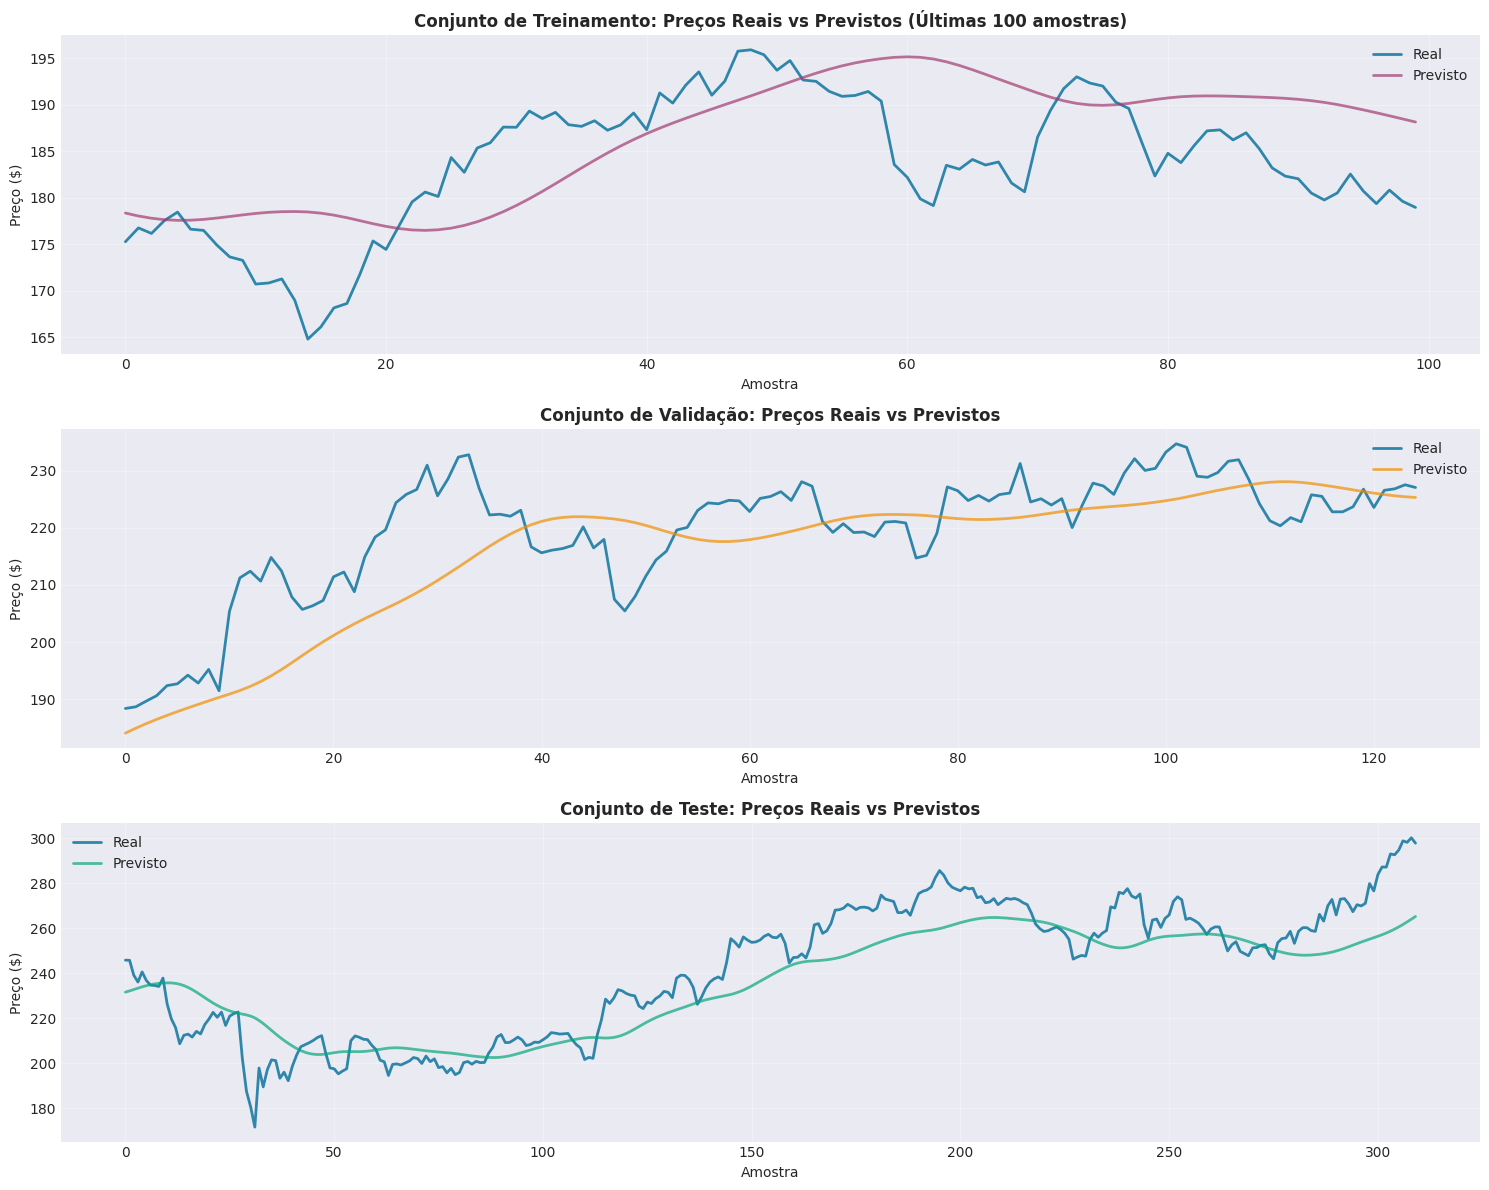

✓ Visualização de previsões salva!

📊 Previsões de Teste de Amostra (Últimas 5 amostras):
Real         | Previsto     | Erro ($)     | Erro (%)  
--------------------------------------------------
294.80       | 260.59       | 34.21        | 11.60     %
298.87       | 261.66       | 37.21        | 12.45     %
298.21       | 262.80       | 35.41        | 11.87     %
300.23       | 264.00       | 36.23        | 12.07     %
297.84       | 265.24       | 32.60        | 10.95     %


In [10]:
# Fazer previsões em todos os conjuntos de dados
print("Fazendo previsões...")

train_pred = lstm_model.predict(X_train)
train_pred = scaler.inverse_transform(train_pred)
y_train_actual = scaler.inverse_transform(y_train.reshape(-1, 1))

val_pred = lstm_model.predict(X_val)
val_pred = scaler.inverse_transform(val_pred)
y_val_actual = scaler.inverse_transform(y_val.reshape(-1, 1))

test_pred = lstm_model.predict(X_test)
test_pred = scaler.inverse_transform(test_pred)
y_test_actual = scaler.inverse_transform(y_test.reshape(-1, 1))

print("✓ Previsões concluídas!")

# Criar visualização comparando previsões vs real
fig, axes = plt.subplots(3, 1, figsize=(15, 12))

# Previsões de treinamento
axes[0].plot(y_train_actual[-100:], label='Real', linewidth=2, color='#2E86AB')
axes[0].plot(train_pred[-100:], label='Previsto', linewidth=2, color='#A23B72', alpha=0.7)
axes[0].set_title('Conjunto de Treinamento: Preços Reais vs Previstos (Últimas 100 amostras)', fontsize=12, fontweight='bold')
axes[0].set_xlabel('Amostra')
axes[0].set_ylabel('Preço ($)')
axes[0].legend()
axes[0].grid(True, alpha=0.3)

# Previsões de validação
axes[1].plot(y_val_actual, label='Real', linewidth=2, color='#2E86AB')
axes[1].plot(val_pred, label='Previsto', linewidth=2, color='#F18F01', alpha=0.7)
axes[1].set_title('Conjunto de Validação: Preços Reais vs Previstos', fontsize=12, fontweight='bold')
axes[1].set_xlabel('Amostra')
axes[1].set_ylabel('Preço ($)')
axes[1].legend()
axes[1].grid(True, alpha=0.3)

# Previsões de teste
axes[2].plot(y_test_actual, label='Real', linewidth=2, color='#2E86AB')
axes[2].plot(test_pred, label='Previsto', linewidth=2, color='#06A77D', alpha=0.7)
axes[2].set_title('Conjunto de Teste: Preços Reais vs Previstos', fontsize=12, fontweight='bold')
axes[2].set_xlabel('Amostra')
axes[2].set_ylabel('Preço ($)')
axes[2].legend()
axes[2].grid(True, alpha=0.3)

plt.tight_layout()
plt.savefig('/home/raulg/dev/laughing-couscous/models/05_predictions_vs_actual.png', dpi=150, bbox_inches='tight')
plt.show()

print("✓ Visualização de previsões salva!")

# Exibir previsões de amostra
print("\n📊 Previsões de Teste de Amostra (Últimas 5 amostras):")
print(f"{'Real':<12} | {'Previsto':<12} | {'Erro ($)':<12} | {'Erro (%)':<10}")
print("-" * 50)
for i in range(-5, 0):
    actual = y_test_actual[i][0]
    predicted = test_pred[i][0]
    error_abs = actual - predicted
    error_pct = (error_abs / actual) * 100
    print(f"{actual:<12.2f} | {predicted:<12.2f} | {error_abs:<12.2f} | {error_pct:<10.2f}%")

## 9. Salvando o modelo para usar na API.

Salvaremos o modelo treinado em formato .h5 para ser utilizado pela API.

In [11]:
import pickle
import json

# Salvar modelo
model_path = '/home/raulg/dev/laughing-couscous/models/lstm_model.h5'
lstm_model.save(model_path)
print(f"✓ Modelo salvo em {model_path}")

# Salvar escalador
scaler_path = '/home/raulg/dev/laughing-couscous/models/scaler.pkl'
with open(scaler_path, 'wb') as f:
    pickle.dump(scaler, f)
print(f"✓ Escalador salvo em {scaler_path}")

# Salvar informações do modelo
model_info = {
    'symbol': STOCK_SYMBOL,
    'lookback_period': LOOKBACK_PERIOD,
    'lstm_units': LSTM_UNITS,
    'dropout_rate': DROPOUT_RATE,
    'epochs_trained': len(history['loss']),
    'batch_size': BATCH_SIZE,
    'data_start_date': START_DATE,
    'data_end_date': END_DATE,
    'training_date': datetime.now().isoformat(),
    'test_metrics': {k: float(v) for k, v in test_metrics.items()},
    'validation_metrics': {k: float(v) for k, v in val_metrics.items()},
    'training_metrics': {k: float(v) for k, v in train_metrics.items()},
}

model_info_path = '/home/raulg/dev/laughing-couscous/models/model_info.json'
with open(model_info_path, 'w') as f:
    json.dump(model_info, f, indent=4)
print(f"✓ Informações do modelo salvas em {model_info_path}")

print("\n📦 Artefatos do modelo salvos com sucesso!")
print(f"\nConfiguração do Modelo:")
for key, value in model_info.items():
    if isinstance(value, dict):
        print(f"  {key}:")
        for k, v in value.items():
            if isinstance(v, float):
                print(f"    {k}: {v:.6f}")
            else:
                print(f"    {k}: {v}")
    else:
        print(f"  {key}: {value}")

INFO:src.models.lstm_model:Modelo salvo em /home/raulg/dev/laughing-couscous/models/lstm_model.h5


✓ Modelo salvo em /home/raulg/dev/laughing-couscous/models/lstm_model.h5
✓ Escalador salvo em /home/raulg/dev/laughing-couscous/models/scaler.pkl
✓ Informações do modelo salvas em /home/raulg/dev/laughing-couscous/models/model_info.json

📦 Artefatos do modelo salvos com sucesso!

Configuração do Modelo:
  symbol: AAPL
  lookback_period: 60
  lstm_units: 50
  dropout_rate: 0.2
  epochs_trained: 12
  batch_size: 32
  data_start_date: 2019-01-01
  data_end_date: 2026-05-19
  training_date: 2026-05-19T19:18:02.518889
  test_metrics:
    MAE: 11.117527
    RMSE: 13.988560
    MAPE: 0.045499
  validation_metrics:
    MAE: 6.600288
    RMSE: 8.369155
    MAPE: 0.030170
  training_metrics:
    MAE: 5.864699
    RMSE: 7.614460
    MAPE: 0.052630
